# Week 6 — Feature Engineering and Updated Model Comparison

## Objective

This notebook extends the Week 5 model comparison by introducing additional property-level and geographic features for predicting `ClosePrice`.

The Week 6 analysis has four main objectives:

1. Add the newly available `CRMLSSold202606.csv` sold-property dataset.
2. Engineer additional property features, including:
   - bedroom-to-bathroom ratio,
   - living area per bedroom,
   - living area per bathroom,
   - lot coverage,
   - property age and property age squared.
3. Add a more detailed geographic layer by assigning each property to a California school district using a spatial join between property coordinates and the California School District Areas boundary data.
4. Re-train and compare Linear Regression, Decision Tree, and Random Forest models using:
   - the original Week 5 feature set;
   - the expanded Week 6 feature set.

To simulate the production use case, the most recent available month, **June 2026**, is reserved as unseen test data. The preceding month, **May 2026**, is used for validation when selecting the training-window length and model parameters.

The old and new feature sets are evaluated using the same chronological split, training window, target filtering rules, and model definitions. This ensures that changes in model performance can be attributed primarily to the newly engineered features rather than to differences in the test period.

In [3]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


## Import Libraries

In [4]:
import os
import time
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler
)
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

warnings.filterwarnings("ignore")

sns.set(style="whitegrid")

pd.set_option("display.max_columns", 150)

RANDOM_SEED = 42
TARGET = "ClosePrice"

## 1. Load the Historical Dataset and June 2026 Update

The Week 3 cleaned and geographically enriched dataset contains sold properties through May 2026. The newly available `CRMLSSold202606.csv` file is then loaded and appended so that June 2026 can be used as the latest unseen test month.

The June records are processed using the same core eligibility rules as the historical modeling data:

- `PropertyType == "Residential"`
- `PropertySubType == "SingleFamilyResidence"`
- valid `CloseDate`
- positive, nonmissing `ClosePrice`

The historical and June datasets are combined before feature engineering and chronological model evaluation.

In [5]:
DATA_DIR = (
    "/content/drive/MyDrive/"
    "IDX_Exchange_Su26/data"
)

HISTORICAL_ENRICHED_PATH = os.path.join(
    DATA_DIR,
    "crmls_sfr_avm_cleaned_enriched_202501_202605.csv"
)

HISTORICAL_CLEANED_PATH = os.path.join(
    DATA_DIR,
    "crmls_sfr_quality_cleaned_202501_202605.csv"
)

JUNE_RAW_PATH = os.path.join(
    DATA_DIR,
    "CRMLSSold202606.csv"
)

# Prefer the school-district-enriched historical file.
if os.path.exists(HISTORICAL_ENRICHED_PATH):
    historical_path = HISTORICAL_ENRICHED_PATH
elif os.path.exists(HISTORICAL_CLEANED_PATH):
    historical_path = HISTORICAL_CLEANED_PATH
else:
    raise FileNotFoundError(
        "The historical cleaned dataset was not found."
    )

if not os.path.exists(JUNE_RAW_PATH):
    raise FileNotFoundError(
        f"June 2026 file was not found: {JUNE_RAW_PATH}"
    )

historical_df = pd.read_csv(
    historical_path,
    low_memory=False
)

june_df = pd.read_csv(
    JUNE_RAW_PATH,
    low_memory=False
)

print("Historical dataset:", historical_path)
print("Historical shape:", historical_df.shape)

print("\nJune dataset:", JUNE_RAW_PATH)
print("June raw shape:", june_df.shape)

Historical dataset: /content/drive/MyDrive/IDX_Exchange_Su26/data/crmls_sfr_avm_cleaned_enriched_202501_202605.csv
Historical shape: (181237, 93)

June dataset: /content/drive/MyDrive/IDX_Exchange_Su26/data/CRMLSSold202606.csv
June raw shape: (24507, 78)


In [9]:
# Apply the required property eligibility filters
# to the newly received June dataset.

if "PropertyType" in june_df.columns:
    june_df = june_df[
        june_df["PropertyType"]
        .astype(str)
        .str.strip()
        .eq("Residential")
    ].copy()

if "PropertySubType" in june_df.columns:
    june_df = june_df[
        june_df["PropertySubType"]
        .astype(str)
        .str.strip()
        .eq("SingleFamilyResidence")
    ].copy()

june_df["CloseDate"] = pd.to_datetime(
    june_df["CloseDate"],
    errors="coerce"
)

june_df[TARGET] = pd.to_numeric(
    june_df[TARGET],
    errors="coerce"
)

june_df = june_df[
    june_df["CloseDate"].notna()
    & june_df[TARGET].notna()
    & (june_df[TARGET] > 0)
].copy()

print("June rows after SFR and target filtering:")
print(len(june_df))

print("\nJune date range:")
print(
    june_df["CloseDate"].min(),
    "to",
    june_df["CloseDate"].max()
)
june_months = (
    june_df["CloseDate"]
    .dt.to_period("M")
    .astype(str)
    .value_counts()
    .sort_index()
)

print("\nJune file month counts:")
print(june_months)

June rows after SFR and target filtering:
12858

June date range:
2026-06-01 00:00:00 to 2026-06-30 00:00:00

June file month counts:
CloseDate
2026-06    12858
Name: count, dtype: int64


## Assign June 2026 Properties to School Districts

The historical enriched dataset already contains a school-district feature created during Week 3. The newly received June 2026 records do not yet contain this geographic layer.

Each June property is converted into a geographic point using its longitude and latitude. The property points are then spatially joined to the California school-district boundary polygons.

Only the district label is retained for modeling. The polygon geometry is not used as a machine-learning input.

In [16]:
DISTRICT_NAME_COLUMN = "DistrictName"

if DISTRICT_NAME_COLUMN not in school_districts.columns:
    raise KeyError(
        f"{DISTRICT_NAME_COLUMN} was not found in "
        "the school district boundary file."
    )

print(
    "District-name column selected:",
    DISTRICT_NAME_COLUMN
)

print(
    "Number of district boundary records:",
    len(school_districts)
)

print(
    "Number of unique district names:",
    school_districts[
        DISTRICT_NAME_COLUMN
    ].nunique()
)

display(
    school_districts[
        [
            DISTRICT_NAME_COLUMN,
            "CountyName",
            "DistrictType",
            "geometry"
        ]
    ].head()
)

District-name column selected: DistrictName
Number of district boundary records: 936
Number of unique district names: 925


,DistrictName,CountyName,DistrictType,geometry
0,Alameda Unified,Alameda,Unified,"MULTIPOLYGON (((-13606222.82 4540862.699, -136..."
1,Albany City Unified,Alameda,Unified,"POLYGON ((-13612893.866 4565099.707, -13612896..."
2,Berkeley Unified,Alameda,Unified,"POLYGON ((-13609482.48 4565074.597, -13609483...."
3,Castro Valley Unified,Alameda,Unified,"MULTIPOLYGON (((-13582508.535 4529067.071, -13..."
4,Emery Unified,Alameda,Unified,"POLYGON ((-13613999.038 4555592.769, -13614126..."


In [17]:
required_coordinate_columns = [
    "Latitude",
    "Longitude"
]

missing_coordinate_columns = [
    col
    for col in required_coordinate_columns
    if col not in june_df.columns
]

if missing_coordinate_columns:
    raise KeyError(
        "June data is missing coordinate columns: "
        f"{missing_coordinate_columns}"
    )

# Convert coordinates to numeric.
june_df["Latitude"] = pd.to_numeric(
    june_df["Latitude"],
    errors="coerce"
)

june_df["Longitude"] = pd.to_numeric(
    june_df["Longitude"],
    errors="coerce"
)

# Give every June property a temporary unique row ID.
june_df = june_df.reset_index(drop=True).copy()
june_df["_june_row_id"] = np.arange(len(june_df))

# Approximate California coordinate bounds.
valid_coordinate_mask = (
    june_df["Latitude"].between(32, 43)
    & june_df["Longitude"].between(-125, -113)
)

june_valid_coordinates = june_df.loc[
    valid_coordinate_mask
].copy()

june_invalid_coordinates = june_df.loc[
    ~valid_coordinate_mask
].copy()

print(
    "June properties with valid coordinates:",
    len(june_valid_coordinates)
)

print(
    "June properties without valid coordinates:",
    len(june_invalid_coordinates)
)

June properties with valid coordinates: 12854
June properties without valid coordinates: 4


In [18]:
# Convert June property coordinates into point geometry.
june_points = gpd.GeoDataFrame(
    june_valid_coordinates,
    geometry=gpd.points_from_xy(
        june_valid_coordinates["Longitude"],
        june_valid_coordinates["Latitude"]
    ),
    crs="EPSG:4326"
)

# Convert district boundaries to the same CRS.
if school_districts.crs is None:
    raise ValueError(
        "The school-district boundary file has no CRS."
    )

school_districts_wgs84 = (
    school_districts
    .to_crs("EPSG:4326")
)

# Keep only the district name and geometry.
district_geometry = school_districts_wgs84[
    [
        DISTRICT_NAME_COLUMN,
        "geometry"
    ]
].copy()

# Spatial join: determine which district contains each property.
june_joined = gpd.sjoin(
    june_points,
    district_geometry,
    how="left",
    predicate="within"
)

print(
    "Rows before spatial join:",
    len(june_points)
)

print(
    "Rows after spatial join:",
    len(june_joined)
)

Rows before spatial join: 12854
Rows after spatial join: 16059


In [19]:
june_joined = (
    june_joined
    .rename(
        columns={
            DISTRICT_NAME_COLUMN:
            "DistrictName"
        }
    )
)

# When a property matches more than one polygon,
# retain one district label so every sale remains one row.
june_joined = (
    june_joined
    .sort_values(
        ["_june_row_id", "DistrictName"],
        na_position="last"
    )
    .drop_duplicates(
        subset="_june_row_id",
        keep="first"
    )
    .drop(
        columns=[
            "index_right",
            "geometry"
        ],
        errors="ignore"
    )
)

# Properties without usable coordinates receive a missing district value.
june_invalid_coordinates["DistrictName"] = np.nan

# Recombine valid-coordinate and invalid-coordinate properties.
june_df = pd.concat(
    [
        june_joined,
        june_invalid_coordinates
    ],
    ignore_index=True,
    sort=False
)

june_df = (
    june_df
    .sort_values("_june_row_id")
    .drop(
        columns="_june_row_id",
        errors="ignore"
    )
    .reset_index(drop=True)
)

print("Final June rows:", len(june_df))

print(
    "District match count:",
    june_df["DistrictName"].notna().sum()
)

print(
    "District missing count:",
    june_df["DistrictName"].isna().sum()
)

print(
    "District match rate:",
    f"{june_df['DistrictName'].notna().mean():.2%}"
)

display(
    june_df[
        [
            "Latitude",
            "Longitude",
            "DistrictName"
        ]
    ].head(10)
)

Final June rows: 12858
District match count: 12854
District missing count: 4
District match rate: 99.97%


,Latitude,Longitude,DistrictName
0,33.512219,-117.687028,Capistrano Unified
1,37.326294,-121.832491,Alum Rock Union Elementary
2,33.181751,-117.233819,Vista Unified
3,34.106716,-117.261967,San Bernardino City Unified
4,34.172977,-118.433103,Los Angeles Unified
5,32.823835,-117.257854,San Diego Unified
6,32.770612,-117.200576,San Diego Unified
7,34.120825,-117.310107,San Bernardino City Unified
8,33.796559,-117.950247,Garden Grove Unified
9,37.708626,-122.096458,Castro Valley Unified


## Combine Historical and June 2026 Records

The school-district-enriched historical data and the newly processed June 2026 data are aligned to the same schema and combined into one modeling dataset.

The combined data are then checked for duplicate listing identifiers before chronological model evaluation.

In [20]:
# Align the historical and June columns.
combined_columns = sorted(
    set(historical_df.columns)
    | set(june_df.columns)
)

historical_aligned = historical_df.reindex(
    columns=combined_columns
)

june_aligned = june_df.reindex(
    columns=combined_columns
)

df = pd.concat(
    [
        historical_aligned,
        june_aligned
    ],
    ignore_index=True,
    sort=False
)

print(
    "Combined rows before duplicate handling:",
    len(df)
)

# Remove duplicate listings when a reliable listing key is available.
if "ListingKey" in df.columns:
    duplicate_count = df.duplicated(
        subset=["ListingKey"],
        keep="last"
    ).sum()

    print(
        "Duplicate ListingKey rows:",
        duplicate_count
    )

    df = df.drop_duplicates(
        subset=["ListingKey"],
        keep="last"
    ).copy()

print(
    "Combined rows after duplicate handling:",
    len(df)
)

Combined rows before duplicate handling: 194095
Duplicate ListingKey rows: 10
Combined rows after duplicate handling: 194085


## 4. Prepare the Target and Time Variables

`ClosePrice` is the prediction target. `CloseDate` is converted into a monthly variable so that model selection and testing follow chronological order.

The latest available month, June 2026, is reserved for final testing. May 2026 is used for validation, and only earlier observations are used to select the training-window length and model parameters.

In [21]:
if TARGET not in df.columns:
    raise KeyError(
        f"{TARGET} was not found in the combined dataset."
    )

if "CloseDate" not in df.columns:
    raise KeyError(
        "CloseDate was not found in the combined dataset."
    )

df["CloseDate"] = pd.to_datetime(
    df["CloseDate"],
    errors="coerce"
)

df[TARGET] = pd.to_numeric(
    df[TARGET],
    errors="coerce"
)

df = df[
    df["CloseDate"].notna()
    & df[TARGET].notna()
    & (df[TARGET] > 0)
].copy()

df["close_month"] = (
    df["CloseDate"]
    .dt.to_period("M")
    .astype(str)
)

available_months_check = sorted(
    df["close_month"].unique()
)

print("Available months:")
print(available_months_check)

print(
    "\nNumber of modeling rows:",
    len(df)
)

if "2026-06" not in available_months_check:
    raise ValueError(
        "June 2026 is missing from the combined dataset."
    )

print("\nJune 2026 rows:")
print(
    (df["close_month"] == "2026-06").sum()
)

Available months:
['2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04', '2026-05', '2026-06']

Number of modeling rows: 194085

June 2026 rows:
12858


## 5. Engineer Additional Property Features

The original Week 5 variables are retained as the baseline feature set. Week 6 adds several interpretable property-layout and land-use variables.

The engineered features are:

- `BedBathRatio`: bedrooms divided by bathrooms;
- `LivingAreaPerBedroom`: living area divided by bedrooms;
- `LivingAreaPerBathroom`: living area divided by bathrooms;
- `LotCoverage`: living area divided by lot size;
- `PropertyAgeSquared`: a nonlinear transformation of property age.

`PropertyAge` was already present in the previous Week 5 notebook and is therefore retained in both the old and new feature sets. The new comparison isolates the incremental contribution of the ratio features and the school-district layer.

In [22]:
engineering_source_columns = [
    "YearBuilt",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LivingArea",
    "LotSizeSquareFeet"
]

for col in engineering_source_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

# Property age at the time of sale.
df["PropertyAge"] = (
    df["CloseDate"].dt.year
    - df["YearBuilt"]
)

# Remove impossible property-age values.
df.loc[
    (df["PropertyAge"] < 0)
    | (df["PropertyAge"] > 300),
    "PropertyAge"
] = np.nan

df["PropertyAgeSquared"] = (
    df["PropertyAge"] ** 2
)

# Valid denominators for ratio features.
valid_bathrooms = (
    df["BathroomsTotalInteger"] > 0
)

valid_bedrooms = (
    df["BedroomsTotal"] > 0
)

valid_lot_size = (
    df["LotSizeSquareFeet"] > 0
)

df["BedBathRatio"] = np.where(
    valid_bathrooms,
    (
        df["BedroomsTotal"]
        / df["BathroomsTotalInteger"]
    ),
    np.nan
)

df["LivingAreaPerBedroom"] = np.where(
    valid_bedrooms,
    (
        df["LivingArea"]
        / df["BedroomsTotal"]
    ),
    np.nan
)

df["LivingAreaPerBathroom"] = np.where(
    valid_bathrooms,
    (
        df["LivingArea"]
        / df["BathroomsTotalInteger"]
    ),
    np.nan
)

df["LotCoverage"] = np.where(
    valid_lot_size,
    (
        df["LivingArea"]
        / df["LotSizeSquareFeet"]
    ),
    np.nan
)

# Cyclical sale-month features.
sale_month = df["CloseDate"].dt.month

df["month_sin"] = np.sin(
    2 * np.pi * sale_month / 12
)

df["month_cos"] = np.cos(
    2 * np.pi * sale_month / 12
)

engineered_features = [
    "PropertyAge",
    "PropertyAgeSquared",
    "BedBathRatio",
    "LivingAreaPerBedroom",
    "LivingAreaPerBathroom",
    "LotCoverage",
    "month_sin",
    "month_cos"
]

display(
    df[
        [
            "CloseDate",
            "close_month"
        ] + engineered_features
    ].head()
)

,CloseDate,close_month,PropertyAge,PropertyAgeSquared,BedBathRatio,LivingAreaPerBedroom,LivingAreaPerBathroom,LotCoverage,month_sin,month_cos
0,2025-01-01,2025-01,58.0,3364.0,1.333333,520.500000,694.000000,0.206139,0.5,0.866025
1,2025-01-01,2025-01,23.0,529.0,1.500000,438.666667,658.000000,0.274682,0.5,0.866025
2,2025-01-01,2025-01,1.0,1.0,1.250000,630.400000,788.000000,0.498498,0.5,0.866025
3,2025-01-01,2025-01,70.0,4900.0,1.333333,525.250000,700.333333,0.161790,0.5,0.866025
4,2025-01-01,2025-01,30.0,900.0,1.000000,545.000000,545.000000,0.075069,0.5,0.866025


In [23]:
feature_distribution_columns = [
    "PropertyAge",
    "BedBathRatio",
    "LivingAreaPerBedroom",
    "LivingAreaPerBathroom",
    "LotCoverage"
]

display(
    df[
        feature_distribution_columns
    ].describe(
        percentiles=[
            0.01,
            0.05,
            0.50,
            0.95,
            0.99
        ]
    ).T
)

,count,mean,std,min,1%,5%,50%,95%,99%,max
PropertyAge,193954.0,49.442641,27.614791,0.0,0.000000,3.000000,49.000000,99.000000,115.000000,249.000000
BedBathRatio,194004.0,1.452509,0.471710,0.0,0.666667,0.833333,1.500000,2.000000,3.000000,7.500000
LivingAreaPerBedroom,193896.0,581.246728,198.143762,0.0,301.750000,350.000000,542.200000,945.333333,1250.336667,4286.600000
LivingAreaPerBathroom,193904.0,789.706231,197.714363,0.0,433.500000,518.666667,767.333333,1136.212500,1361.333333,4900.000000
LotCoverage,190508.0,18.973036,566.345531,0.0,0.006872,0.042688,0.236455,0.598661,0.995214,60566.666667


In [24]:
df.loc[
    ~df["BedBathRatio"].between(
        0.1,
        10
    ),
    "BedBathRatio"
] = np.nan

df.loc[
    ~df["LivingAreaPerBedroom"].between(
        100,
        5000
    ),
    "LivingAreaPerBedroom"
] = np.nan

df.loc[
    ~df["LivingAreaPerBathroom"].between(
        100,
        10000
    ),
    "LivingAreaPerBathroom"
] = np.nan

df.loc[
    ~df["LotCoverage"].between(
        0.01,
        5
    ),
    "LotCoverage"
] = np.nan

## 6. Define the Old and New Feature Sets and Prevent Data Leakage

Two feature specifications are compared.

### Old feature set

The old feature set reproduces the property, location, amenity, missingness, and seasonal predictors used before the Week 6 update. It excludes the school-district layer and the newly engineered ratio variables.

### New feature set

The new feature set contains all old predictors and additionally includes:

- `DistrictName`;
- `PropertyAgeSquared`;
- `BedBathRatio`;
- `LivingAreaPerBedroom`;
- `LivingAreaPerBathroom`;
- `LotCoverage`.

Both feature sets exclude list prices, post-sale variables, identifiers, target-derived variables, and other potential leakage fields. They are evaluated on exactly the same training and test observations.

In [25]:
LEAKAGE_COLUMNS = {
    "ClosePrice",
    "ListPrice",
    "OriginalListPrice",
    "ClosePrice_to_ListPrice_ratio",
    "DaysOnMarket",
    "CloseDate",
    "PurchaseContractDate",
    "ContractStatusChangeDate",
    "MlsStatus",
    "ListingKey",
    "ListingKeyNumeric",
    "ListingId",
    "UnparsedAddress"
}

old_numeric_candidates = [
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
    "PropertyAge",
    "GarageSpaces",
    "Stories",
    "Latitude",
    "Longitude",
    "month_sin",
    "month_cos",
    "LivingArea_missing",
    "BathroomsTotalInteger_missing",
    "LotSizeSquareFeet_missing",
    "YearBuilt_missing",
    "GarageSpaces_missing",
    "Stories_missing"
]

old_categorical_candidates = [
    "City",
    "PostalCode",
    "CountyOrParish",
    "ViewYN",
    "WaterfrontYN",
    "BasementYN",
    "PoolPrivateYN",
    "AttachedGarageYN",
    "FireplaceYN",
    "NewConstructionYN"
]

new_numeric_candidates = [
    "PropertyAgeSquared",
    "BedBathRatio",
    "LivingAreaPerBedroom",
    "LivingAreaPerBathroom",
    "LotCoverage"
]

new_categorical_candidates = [
    "DistrictName"
]

old_numeric_features = [
    col
    for col in old_numeric_candidates
    if col in df.columns
    and col not in LEAKAGE_COLUMNS
]

old_categorical_features = [
    col
    for col in old_categorical_candidates
    if col in df.columns
    and col not in LEAKAGE_COLUMNS
]

new_numeric_features = (
    old_numeric_features
    + [
        col
        for col in new_numeric_candidates
        if col in df.columns
        and col not in old_numeric_features
        and col not in LEAKAGE_COLUMNS
    ]
)

new_categorical_features = (
    old_categorical_features
    + [
        col
        for col in new_categorical_candidates
        if col in df.columns
        and col not in old_categorical_features
        and col not in LEAKAGE_COLUMNS
    ]
)

FEATURE_SETS = {
    "Old Features": {
        "numeric": old_numeric_features,
        "categorical": old_categorical_features
    },
    "New Features": {
        "numeric": new_numeric_features,
        "categorical": new_categorical_features
    }
}

for feature_set_name, specification in FEATURE_SETS.items():
    print("\n" + feature_set_name)
    print("-" * 60)

    print(
        "Numerical features:",
        specification["numeric"]
    )

    print(
        "\nCategorical features:",
        specification["categorical"]
    )

    print(
        "\nTotal raw features:",
        len(
            specification["numeric"]
            + specification["categorical"]
        )
    )


Old Features
------------------------------------------------------------
Numerical features: ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet', 'PropertyAge', 'GarageSpaces', 'Stories', 'Latitude', 'Longitude', 'month_sin', 'month_cos', 'LivingArea_missing', 'BathroomsTotalInteger_missing', 'LotSizeSquareFeet_missing', 'YearBuilt_missing', 'GarageSpaces_missing', 'Stories_missing']

Categorical features: ['City', 'PostalCode', 'CountyOrParish', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', 'AttachedGarageYN', 'FireplaceYN', 'NewConstructionYN']

Total raw features: 27

New Features
------------------------------------------------------------
Numerical features: ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet', 'PropertyAge', 'GarageSpaces', 'Stories', 'Latitude', 'Longitude', 'month_sin', 'month_cos', 'LivingArea_missing', 'BathroomsTotalInteger_missing', 'LotSizeSquareFeet_missing', 'YearBuilt_missing', 'GarageSpaces_

In [26]:
all_numeric_features = sorted(
    set(
        old_numeric_features
        + new_numeric_features
    )
)

all_categorical_features = sorted(
    set(
        old_categorical_features
        + new_categorical_features
    )
)

for col in all_numeric_features:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    ).astype(float)

for col in all_categorical_features:
    missing_mask = df[col].isna()

    df[col] = df[col].astype(object)

    df.loc[~missing_mask, col] = (
        df.loc[~missing_mask, col]
        .astype(str)
    )

    df.loc[missing_mask, col] = np.nan

all_feature_columns = (
    all_numeric_features
    + all_categorical_features
)

print(
    "Feature types prepared for scikit-learn."
)

remaining_missing = (
    df[all_feature_columns]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print(
    "\nMissing values handled later by model pipelines:"
)

print(
    remaining_missing[
        remaining_missing > 0
    ]
)

Feature types prepared for scikit-learn.

Missing values handled later by model pipelines:
WaterfrontYN                     193978
BasementYN                       189392
AttachedGarageYN                  23264
Stories                           20955
ViewYN                            17483
PoolPrivateYN                     15421
NewConstructionYN                 14719
Stories_missing                   12858
BathroomsTotalInteger_missing     12858
YearBuilt_missing                 12858
GarageSpaces_missing              12858
LotSizeSquareFeet_missing         12858
LivingArea_missing                12858
GarageSpaces                       7540
LotCoverage                        6655
LotSizeSquareFeet                  3373
LivingAreaPerBedroom                197
LivingAreaPerBathroom               191
FireplaceYN                         140
PropertyAgeSquared                  131
PropertyAge                         131
BedBathRatio                        126
LivingArea                   

## 7. Evaluation Metrics

R² is the primary model-performance metric. MAE, RMSE, MAPE, and MdAPE are also reported to describe dollar error, average percentage error, and typical percentage error.

In [27]:
def calculate_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    percentage_errors = (
        np.abs(y_true - y_pred)
        / np.abs(y_true)
    ) * 100

    return {
        "R2": r2_score(y_true, y_pred),

        "MAE": mean_absolute_error(
            y_true,
            y_pred
        ),

        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        ),

        "MAPE": (
            mean_absolute_percentage_error(
                y_true,
                y_pred
            ) * 100
        ),

        "MdAPE": np.median(
            percentage_errors
        )
    }

## 8. Build Model-Specific Preprocessing Pipelines

Separate preprocessing pipelines are constructed for the old and new feature sets.

Linear Regression uses median imputation and standardization for numerical features and one-hot encoding for categorical variables.

Decision Tree and Random Forest use median numerical imputation and ordinal encoding for categorical variables. Tree models do not require numerical scaling.

In [28]:
def build_preprocessors(
    numeric_features,
    categorical_features
):
    linear_numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),
            (
                "scaler",
                StandardScaler()
            )
        ]
    )

    linear_categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),
            (
                "encoder",
                OneHotEncoder(
                    handle_unknown="ignore",
                    drop="first",
                    min_frequency=20
                )
            )
        ]
    )

    linear_preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                linear_numeric_pipeline,
                numeric_features
            ),
            (
                "categorical",
                linear_categorical_pipeline,
                categorical_features
            )
        ]
    )

    tree_numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            )
        ]
    )

    tree_categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),
            (
                "encoder",
                OrdinalEncoder(
                    handle_unknown="use_encoded_value",
                    unknown_value=-1
                )
            )
        ]
    )

    tree_preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                tree_numeric_pipeline,
                numeric_features
            ),
            (
                "categorical",
                tree_categorical_pipeline,
                categorical_features
            )
        ]
    )

    return (
        linear_preprocessor,
        tree_preprocessor
    )

## 9. Select the Training Window Using May 2026

The newest available month, June 2026, is reserved as the final unseen test month.

May 2026 is used as the validation month when comparing candidate training-window lengths. The window search uses the new Week 6 feature set. After selecting the best window, the same window is applied to both the old and new feature sets for a fair comparison.

In [29]:
available_months = sorted(
    df["close_month"]
    .dropna()
    .unique()
)

test_month = available_months[-1]
validation_month = available_months[-2]

test_period = pd.Period(
    test_month,
    freq="M"
)

validation_period = pd.Period(
    validation_month,
    freq="M"
)

training_end_period = (
    validation_period - 1
)

df_month_period = pd.PeriodIndex(
    df["close_month"],
    freq="M"
)

print("Validation month:", validation_month)
print("Final test month:", test_month)

if test_month != "2026-06":
    raise ValueError(
        f"Expected June 2026 as test month, "
        f"but found {test_month}."
    )

if validation_month != "2026-05":
    raise ValueError(
        f"Expected May 2026 as validation month, "
        f"but found {validation_month}."
    )

Validation month: 2026-05
Final test month: 2026-06


In [30]:
window_numeric_features = (
    FEATURE_SETS["New Features"]["numeric"]
)

window_categorical_features = (
    FEATURE_SETS["New Features"]["categorical"]
)

window_feature_columns = (
    window_numeric_features
    + window_categorical_features
)

window_linear_preprocessor, _ = (
    build_preprocessors(
        window_numeric_features,
        window_categorical_features
    )
)

# Compare Training Windows
TRAINING_WINDOW_CANDIDATES = [
    3,
    6,
    9,
    12,
    15
]

window_results = []

for window in TRAINING_WINDOW_CANDIDATES:

    training_start_period = (
        training_end_period
        - (window - 1)
    )

    train_mask = (
        (df_month_period >= training_start_period)
        & (df_month_period <= training_end_period)
    )

    validation_mask = (
        df_month_period == validation_period
    )

    train_data = df.loc[
        train_mask
    ].copy()

    validation_data = df.loc[
        validation_mask
    ].copy()

    if train_data.empty:
        continue

    # Learn ClosePrice outlier thresholds
    # from training data only.
    lower_price = train_data[
        TARGET
    ].quantile(0.005)

    upper_price = train_data[
        TARGET
    ].quantile(0.995)

    train_data = train_data[
        train_data[TARGET].between(
            lower_price,
            upper_price
        )
    ].copy()

    validation_data = validation_data[
        validation_data[TARGET].between(
            lower_price,
            upper_price
        )
    ].copy()

    model = Pipeline(
        steps=[
            (
                "preprocessor",
                window_linear_preprocessor
            ),
            (
                "model",
                LinearRegression()
            )
        ]
    )

    model.fit(
        train_data[window_feature_columns],
        train_data[TARGET]
    )

    validation_predictions = model.predict(
        validation_data[window_feature_columns]
    )

    metrics = calculate_metrics(
        validation_data[TARGET],
        validation_predictions
    )

    window_results.append({
        "Training_Window_Months": window,
        "Training_Start": str(
            training_start_period
        ),
        "Training_End": str(
            training_end_period
        ),
        "Validation_Month": validation_month,
        "Training_Rows": len(train_data),
        "Validation_Rows": len(
            validation_data
        ),
        "Validation_R2": metrics["R2"],
        "Validation_MAE": metrics["MAE"],
        "Validation_MAPE": metrics["MAPE"],
        "Validation_MdAPE": metrics["MdAPE"]
    })

window_results_df = pd.DataFrame(
    window_results
).sort_values(
    "Validation_R2",
    ascending=False
).reset_index(drop=True)

window_results_df

,Training_Window_Months,Training_Start,Training_End,Validation_Month,Training_Rows,Validation_Rows,Validation_R2,Validation_MAE,Validation_MAPE,Validation_MdAPE
0,15,2025-02,2026-04,2026-05,159478,11897,0.835901,228552.419207,19.836747,13.943502
1,12,2025-05,2026-04,2026-05,128501,11900,0.835122,230413.487022,19.968634,13.865158
2,9,2025-08,2026-04,2026-05,93331,11905,0.834059,231480.526049,20.022040,13.932591
3,6,2025-11,2026-04,2026-05,58774,11906,0.826806,238750.050980,20.784575,14.300472
4,3,2026-02,2026-04,2026-05,31421,11906,0.808269,255120.462946,22.871270,15.204743


In [31]:
# Select Best X
BEST_X = int(
    window_results_df.loc[
        0,
        "Training_Window_Months"
    ]
)

print(
    "Selected training window:",
    BEST_X,
    "months"
)

print(
    "Best validation R²:",
    f"{window_results_df.loc[0, 'Validation_R2']:.4f}"
)

Selected training window: 15 months
Best validation R²: 0.8359


## 10. Create the Tuning Training Set and Validation Set

The selected training-window length is used to create the model-tuning data. Decision Tree and Random Forest parameters are tuned using the new Week 6 feature set and May 2026 validation data.

The selected parameters are subsequently applied to both the old and new feature sets so that their final comparison uses the same model settings.

In [32]:
tuning_train_start = (
    training_end_period
    - (BEST_X - 1)
)

tuning_train_mask = (
    (df_month_period >= tuning_train_start)
    & (df_month_period <= training_end_period)
)

validation_mask = (
    df_month_period == validation_period
)

tuning_train_df = df.loc[
    tuning_train_mask
].copy()

validation_df = df.loc[
    validation_mask
].copy()

tuning_lower_price = (
    tuning_train_df[TARGET]
    .quantile(0.005)
)

tuning_upper_price = (
    tuning_train_df[TARGET]
    .quantile(0.995)
)

tuning_train_df = tuning_train_df[
    tuning_train_df[TARGET].between(
        tuning_lower_price,
        tuning_upper_price
    )
].copy()

validation_df = validation_df[
    validation_df[TARGET].between(
        tuning_lower_price,
        tuning_upper_price
    )
].copy()

tuning_numeric_features = (
    FEATURE_SETS["New Features"]["numeric"]
)

tuning_categorical_features = (
    FEATURE_SETS["New Features"]["categorical"]
)

tuning_feature_columns = (
    tuning_numeric_features
    + tuning_categorical_features
)

_, tuning_tree_preprocessor = (
    build_preprocessors(
        tuning_numeric_features,
        tuning_categorical_features
    )
)

X_tuning_train = tuning_train_df[
    tuning_feature_columns
]

y_tuning_train = tuning_train_df[
    TARGET
]

X_validation = validation_df[
    tuning_feature_columns
]

y_validation = validation_df[
    TARGET
]

print(
    "Tuning training period:",
    tuning_train_df["close_month"].min(),
    "to",
    tuning_train_df["close_month"].max()
)

print("Validation month:", validation_month)
print("Training rows:", len(tuning_train_df))
print("Validation rows:", len(validation_df))

Tuning training period: 2025-02 to 2026-04
Validation month: 2026-05
Training rows: 159478
Validation rows: 11897


## 8. Tune the Decision Tree

A small validation search is used to control tree depth and minimum leaf size. These parameters help reduce overfitting.

In [33]:
decision_tree_candidates = [
    {
        "max_depth": 6,
        "min_samples_leaf": 10
    },
    {
        "max_depth": 8,
        "min_samples_leaf": 10
    },
    {
        "max_depth": 10,
        "min_samples_leaf": 10
    },
    {
        "max_depth": 12,
        "min_samples_leaf": 10
    },
    {
        "max_depth": 8,
        "min_samples_leaf": 30
    },
    {
        "max_depth": 12,
        "min_samples_leaf": 30
    }
]

decision_tree_results = []

for params in decision_tree_candidates:

    model = Pipeline(
        steps=[
            (

                "preprocessor",
                tuning_tree_preprocessor

            ),
            (
                "model",
                DecisionTreeRegressor(
                    random_state=RANDOM_SEED,
                    max_depth=params[
                        "max_depth"
                    ],
                    min_samples_leaf=params[
                        "min_samples_leaf"
                    ]
                )
            )
        ]
    )

    start_time = time.time()

    model.fit(
        X_tuning_train,
        y_tuning_train
    )

    validation_predictions = model.predict(
        X_validation
    )

    elapsed_time = (
        time.time() - start_time
    )

    metrics = calculate_metrics(
        y_validation,
        validation_predictions
    )

    decision_tree_results.append({
        "max_depth": params["max_depth"],
        "min_samples_leaf": params[
            "min_samples_leaf"
        ],
        "Validation_R2": metrics["R2"],
        "Validation_MAE": metrics["MAE"],
        "Validation_MdAPE": metrics[
            "MdAPE"
        ],
        "Fit_Seconds": elapsed_time
    })

decision_tree_results_df = pd.DataFrame(
    decision_tree_results
).sort_values(
    "Validation_R2",
    ascending=False
).reset_index(drop=True)

decision_tree_results_df

,max_depth,min_samples_leaf,Validation_R2,Validation_MAE,Validation_MdAPE,Fit_Seconds
0,12,10,0.800792,241863.904620,12.761262,5.780816
1,12,30,0.792369,245779.069630,12.987404,4.559329
2,10,10,0.760502,276941.990641,15.420390,5.751204
3,8,10,0.706626,318832.208326,18.419963,4.617155
4,8,30,0.705302,319388.654680,18.419963,5.417937
5,6,10,0.608721,378223.669730,22.243980,4.165645


In [34]:
# Best Decision Tree Parameters
BEST_DT_PARAMS = {
    "max_depth": int(
        decision_tree_results_df.loc[
            0,
            "max_depth"
        ]
    ),

    "min_samples_leaf": int(
        decision_tree_results_df.loc[
            0,
            "min_samples_leaf"
        ]
    )
}

print(
    "Best Decision Tree parameters:",
    BEST_DT_PARAMS
)

print(
    "Best Decision Tree validation R²:",
    f"{decision_tree_results_df.loc[0, 'Validation_R2']:.4f}"
)

Best Decision Tree parameters: {'max_depth': 12, 'min_samples_leaf': 10}
Best Decision Tree validation R²: 0.8008


## 9. Tune the Random Forest

Random Forest averages many Decision Trees to reduce variance. A small validation search is used to compare depth, leaf size, and feature-sampling choices.

In [35]:
random_forest_candidates = [
    {
        "max_depth": 12,
        "min_samples_leaf": 1,
        "max_features": "sqrt"
    },
    {
        "max_depth": 12,
        "min_samples_leaf": 5,
        "max_features": "sqrt"
    },
    {
        "max_depth": 18,
        "min_samples_leaf": 1,
        "max_features": "sqrt"
    },
    {
        "max_depth": 18,
        "min_samples_leaf": 5,
        "max_features": "sqrt"
    },
    {
        "max_depth": None,
        "min_samples_leaf": 1,
        "max_features": 0.7
    },
    {
        "max_depth": None,
        "min_samples_leaf": 5,
        "max_features": 0.7
    }
]

random_forest_results = []

for params in random_forest_candidates:

    model = Pipeline(
        steps=[
            (
                "preprocessor",
                tuning_tree_preprocessor
            ),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=100,
                    random_state=RANDOM_SEED,
                    n_jobs=-1,
                    max_depth=params[
                        "max_depth"
                    ],
                    min_samples_leaf=params[
                        "min_samples_leaf"
                    ],
                    max_features=params[
                        "max_features"
                    ]
                )
            )
        ]
    )

    start_time = time.time()

    model.fit(
        X_tuning_train,
        y_tuning_train
    )

    validation_predictions = model.predict(
        X_validation
    )

    elapsed_time = (
        time.time() - start_time
    )

    metrics = calculate_metrics(
        y_validation,
        validation_predictions
    )

    random_forest_results.append({
        "max_depth": params["max_depth"],
        "min_samples_leaf": params[
            "min_samples_leaf"
        ],
        "max_features": params[
            "max_features"
        ],
        "n_estimators": 100,
        "Validation_R2": metrics["R2"],
        "Validation_MAE": metrics["MAE"],
        "Validation_MdAPE": metrics[
            "MdAPE"
        ],
        "Fit_Seconds": elapsed_time
    })

random_forest_results_df = pd.DataFrame(
    random_forest_results
).sort_values(
    "Validation_R2",
    ascending=False
).reset_index(drop=True)

random_forest_results_df

,max_depth,min_samples_leaf,max_features,n_estimators,Validation_R2,Validation_MAE,Validation_MdAPE,Fit_Seconds
0,NaN,1,0.7,100,0.870838,176030.635576,8.042346,244.774515
1,NaN,5,0.7,100,0.866751,178467.205089,8.147586,189.010051
2,18.0,1,sqrt,100,0.827953,213188.319543,10.585262,48.800383
3,18.0,5,sqrt,100,0.816482,220472.495628,11.065882,44.478856
4,12.0,5,sqrt,100,0.766510,268697.867845,15.795593,34.553353
5,12.0,1,sqrt,100,0.763030,271621.712013,16.063430,35.545258


In [36]:
# Best Random Forest Parameters
best_depth_value = (
    random_forest_results_df.loc[
        0,
        "max_depth"
    ]
)

if pd.isna(best_depth_value):
    best_depth_value = None
else:
    best_depth_value = int(
        best_depth_value
    )

best_max_features = (
    random_forest_results_df.loc[
        0,
        "max_features"
    ]
)

try:
    best_max_features = float(
        best_max_features
    )
except (TypeError, ValueError):
    best_max_features = str(
        best_max_features
    )

BEST_RF_PARAMS = {
    "n_estimators": 100,

    "max_depth": best_depth_value,

    "min_samples_leaf": int(
        random_forest_results_df.loc[
            0,
            "min_samples_leaf"
        ]
    ),

    "max_features": best_max_features
}

print(
    "Best Random Forest parameters:",
    BEST_RF_PARAMS
)

print(
    "Best Random Forest validation R²:",
    f"{random_forest_results_df.loc[0, 'Validation_R2']:.4f}"
)

Best Random Forest parameters: {'n_estimators': 100, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 0.7}
Best Random Forest validation R²: 0.8708


## 13. Final Train/Test Split

After selecting the training-window length and tree-model parameters using May 2026 validation data, the final training period is shifted forward to end in May 2026.

June 2026 is then used once as the final unseen test set. The same training rows, test rows, and target-price bounds are used for both the old and new feature sets.

In [37]:
final_train_end = (
    test_period - 1
)

final_train_start = (
    final_train_end
    - (BEST_X - 1)
)

final_train_mask = (
    (df_month_period >= final_train_start)
    & (df_month_period <= final_train_end)
)

test_mask = (
    df_month_period == test_period
)

final_train_df = df.loc[
    final_train_mask
].copy()

test_df = df.loc[
    test_mask
].copy()

# Learn outlier thresholds
# from final training data only.
final_lower_price = (
    final_train_df[TARGET]
    .quantile(0.005)
)

final_upper_price = (
    final_train_df[TARGET]
    .quantile(0.995)
)

final_train_df = final_train_df[
    final_train_df[TARGET].between(
        final_lower_price,
        final_upper_price
    )
].copy()

test_df = test_df[
    test_df[TARGET].between(
        final_lower_price,
        final_upper_price
    )
].copy()



y_train = final_train_df[
    TARGET
]


y_test = test_df[
    TARGET
]

print(
    "Final training period:",
    final_train_df["close_month"].min(),
    "to",
    final_train_df["close_month"].max()
)

print("Test month:", test_month)
print("Training rows:", len(final_train_df))
print("Test rows:", len(test_df))

print(
    "Frozen target bounds:",
    f"${final_lower_price:,.0f}",
    "to",
    f"${final_upper_price:,.0f}"
)

Final training period: 2025-03 to 2026-05
Test month: 2026-06
Training rows: 162619
Test rows: 12714
Frozen target bounds: $189,000 to $8,800,000


## 14. Train Models with the Old and New Feature Sets

Linear Regression, Decision Tree, and Random Forest are each trained twice:

1. using the old Week 5 feature specification;
2. using the expanded Week 6 feature specification.

This produces six final model results. All models use the same chronological split and the same target observations.

In [ ]:
model_results = []

test_predictions = {}

fitted_models = {}

for feature_set_name, specification in FEATURE_SETS.items():

    numeric_features_current = (
        specification["numeric"]
    )

    categorical_features_current = (
        specification["categorical"]
    )

    feature_columns_current = (
        numeric_features_current
        + categorical_features_current
    )

    (
        linear_preprocessor_current,
        tree_preprocessor_current
    ) = build_preprocessors(
        numeric_features_current,
        categorical_features_current
    )

    X_train_current = final_train_df[
        feature_columns_current
    ]

    X_test_current = test_df[
        feature_columns_current
    ]

    models_current = {
        "Linear Regression": Pipeline(
            steps=[
                (
                    "preprocessor",
                    linear_preprocessor_current
                ),
                (
                    "model",
                    LinearRegression()
                )
            ]
        ),

        "Decision Tree": Pipeline(
            steps=[
                (
                    "preprocessor",
                    tree_preprocessor_current
                ),
                (
                    "model",
                    DecisionTreeRegressor(
                        random_state=RANDOM_SEED,
                        max_depth=BEST_DT_PARAMS[
                            "max_depth"
                        ],
                        min_samples_leaf=BEST_DT_PARAMS[
                            "min_samples_leaf"
                        ]
                    )
                )
            ]
        ),

        "Random Forest": Pipeline(
            steps=[
                (
                    "preprocessor",
                    tree_preprocessor_current
                ),
                (
                    "model",
                    RandomForestRegressor(
                        n_estimators=BEST_RF_PARAMS[
                            "n_estimators"
                        ],
                        random_state=RANDOM_SEED,
                        n_jobs=-1,
                        max_depth=BEST_RF_PARAMS[
                            "max_depth"
                        ],
                        min_samples_leaf=BEST_RF_PARAMS[
                            "min_samples_leaf"
                        ],
                        max_features=BEST_RF_PARAMS[
                            "max_features"
                        ]
                    )
                )
            ]
        )
    }

    for model_name, model in models_current.items():

        print(
            f"Training {model_name} "
            f"with {feature_set_name}..."
        )

        start_time = time.time()

        model.fit(
            X_train_current,
            y_train
        )

        fit_seconds = (
            time.time() - start_time
        )

        train_predictions = model.predict(
            X_train_current
        )

        test_pred = model.predict(
            X_test_current
        )

        train_metrics = calculate_metrics(
            y_train,
            train_predictions
        )

        test_metrics = calculate_metrics(
            y_test,
            test_pred
        )

        model_results.append({
            "Feature_Set": feature_set_name,
            "Model": model_name,
            "Number_of_Raw_Features": len(
                feature_columns_current
            ),
            "Training_Window_Months": BEST_X,
            "Training_Start": str(
                final_train_start
            ),
            "Training_End": str(
                final_train_end
            ),
            "Test_Month": test_month,
            "Train_R2": train_metrics["R2"],
            "Test_R2": test_metrics["R2"],
            "Test_MAE": test_metrics["MAE"],
            "Test_RMSE": test_metrics["RMSE"],
            "Test_MAPE": test_metrics["MAPE"],
            "Test_MdAPE": test_metrics[
                "MdAPE"
            ],
            "Fit_Seconds": fit_seconds
        })

        model_key = (
            feature_set_name,
            model_name
        )

        test_predictions[
            model_key
        ] = test_pred

        fitted_models[
            model_key
        ] = model

results_df = pd.DataFrame(
    model_results
).sort_values(
    [
        "Model",
        "Feature_Set"
    ]
).reset_index(drop=True)

display(results_df)

Training Linear Regression with Old Features...
Training Decision Tree with Old Features...
Training Random Forest with Old Features...
Training Linear Regression with New Features...
Training Decision Tree with New Features...
Training Random Forest with New Features...


In [39]:
old_results = (
    results_df[
        results_df["Feature_Set"]
        == "Old Features"
    ]
    .set_index("Model")
)

new_results = (
    results_df[
        results_df["Feature_Set"]
        == "New Features"
    ]
    .set_index("Model")
)

feature_comparison_df = (
    old_results[
        [
            "Test_R2",
            "Test_MAE",
            "Test_MAPE",
            "Test_MdAPE"
        ]
    ]
    .add_prefix("Old_")
    .join(
        new_results[
            [
                "Test_R2",
                "Test_MAE",
                "Test_MAPE",
                "Test_MdAPE"
            ]
        ].add_prefix("New_")
    )
    .reset_index()
)

feature_comparison_df["R2_Change"] = (
    feature_comparison_df["New_Test_R2"]
    - feature_comparison_df["Old_Test_R2"]
)

feature_comparison_df["MAE_Change"] = (
    feature_comparison_df["New_Test_MAE"]
    - feature_comparison_df["Old_Test_MAE"]
)

feature_comparison_df["MAPE_Change"] = (
    feature_comparison_df["New_Test_MAPE"]
    - feature_comparison_df["Old_Test_MAPE"]
)

feature_comparison_df["MdAPE_Change"] = (
    feature_comparison_df["New_Test_MdAPE"]
    - feature_comparison_df["Old_Test_MdAPE"]
)

display(feature_comparison_df)

,Model,Old_Test_R2,Old_Test_MAE,Old_Test_MAPE,Old_Test_MdAPE,New_Test_R2,New_Test_MAE,New_Test_MAPE,New_Test_MdAPE,R2_Change,MAE_Change,MAPE_Change,MdAPE_Change
0,Decision Tree,0.765430,254213.446343,19.689088,13.084628,0.744898,268148.942390,20.754168,13.887164,-0.020531,13935.496047,1.065080,0.802537
1,Linear Regression,0.823956,244910.828202,22.503345,15.905356,0.826683,243221.390141,21.995113,15.441967,0.002727,-1689.438062,-0.508232,-0.463389
2,Random Forest,0.870224,174078.449019,13.107908,7.885330,0.858225,187169.393242,14.483501,8.978567,-0.011999,13090.944223,1.375593,1.093237


## 15. Compare Old and New Feature-Set Performance

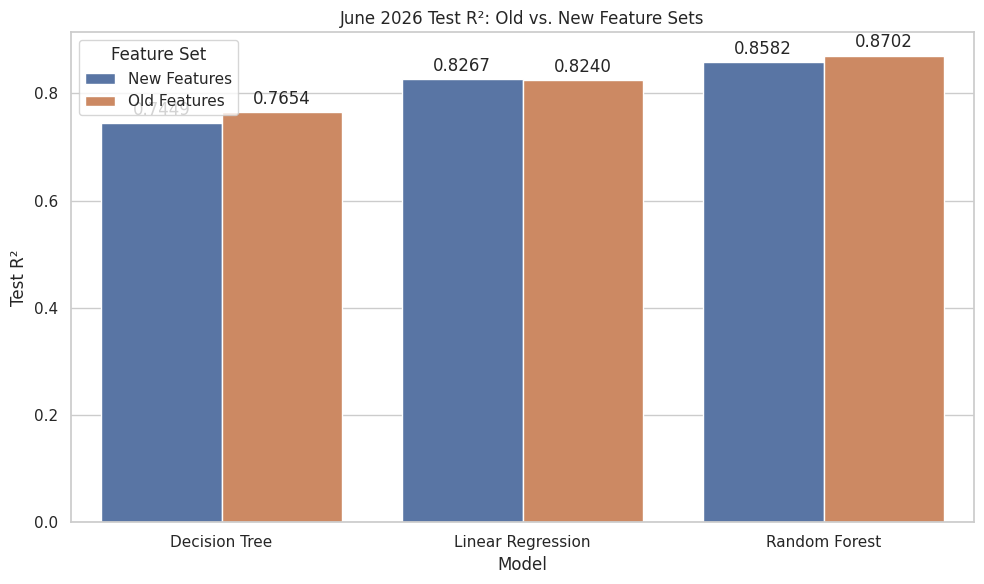

In [40]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=results_df,
    x="Model",
    y="Test_R2",
    hue="Feature_Set"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        padding=3
    )

plt.title(
    "June 2026 Test R²: "
    "Old vs. New Feature Sets"
)

plt.xlabel("Model")
plt.ylabel("Test R²")

plt.legend(
    title="Feature Set"
)

plt.tight_layout()
plt.show()

## 16. Actual vs. Predicted ClosePrice for the New Feature Set

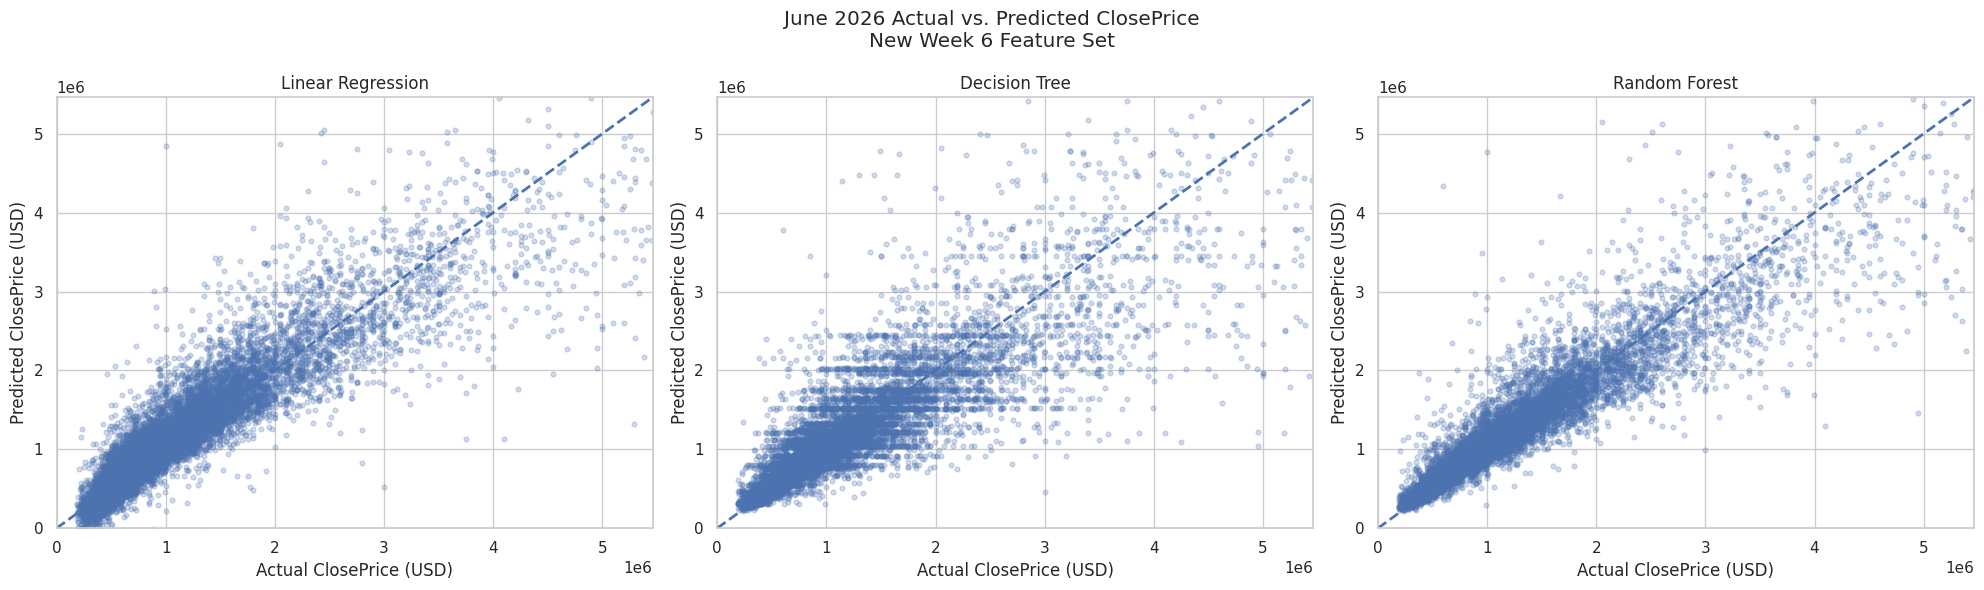

In [41]:
new_feature_predictions = {
    model_name: predictions
    for (
        feature_set_name,
        model_name
    ), predictions in test_predictions.items()
    if feature_set_name == "New Features"
}

plot_limit = max(
    y_test.quantile(0.99),

    max(
        np.quantile(
            prediction,
            0.99
        )
        for prediction
        in new_feature_predictions.values()
    )
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 6)
)

for ax, (
    model_name,
    predictions
) in zip(
    axes,
    new_feature_predictions.items()
):
    ax.scatter(
        y_test,
        predictions,
        alpha=0.25,
        s=12
    )

    ax.plot(
        [0, plot_limit],
        [0, plot_limit],
        linestyle="--",
        linewidth=2
    )

    ax.set_xlim(
        0,
        plot_limit
    )

    ax.set_ylim(
        0,
        plot_limit
    )

    ax.set_title(model_name)

    ax.set_xlabel(
        "Actual ClosePrice (USD)"
    )

    ax.set_ylabel(
        "Predicted ClosePrice (USD)"
    )

plt.suptitle(
    "June 2026 Actual vs. Predicted ClosePrice\n"
    "New Week 6 Feature Set"
)

plt.tight_layout()
plt.show()

## 17. Random Forest Feature Importance with the New Feature Set

In [42]:
rf_pipeline = fitted_models[
    (
        "New Features",
        "Random Forest"
    )
]

rf_preprocessor = rf_pipeline.named_steps[
    "preprocessor"
]

rf_model = rf_pipeline.named_steps[
    "model"
]

rf_feature_names = (
    rf_preprocessor
    .get_feature_names_out()
)

rf_importance_df = pd.DataFrame({
    "Feature": rf_feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

rf_importance_df.head(20)

,Feature,Importance
0,numeric__BathroomsTotalInteger,0.203158
1,numeric__LivingArea,0.188113
2,numeric__Longitude,0.151213
3,numeric__Latitude,0.132162
4,categorical__PostalCode,0.081622
5,numeric__LivingAreaPerBedroom,0.036089
6,categorical__CountyOrParish,0.032481
7,numeric__PropertyAgeSquared,0.021156
8,numeric__LotSizeSquareFeet,0.020147
9,numeric__PropertyAge,0.019570


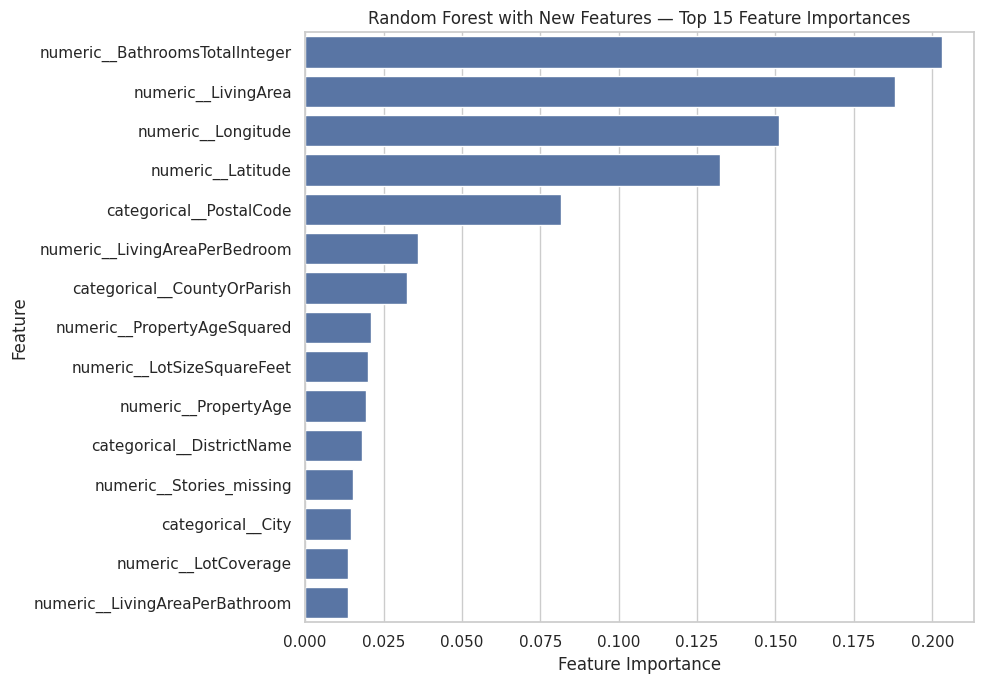

In [43]:
# Plot Feature Importance
plt.figure(figsize=(10, 7))

sns.barplot(
    data=rf_importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title(
    "Random Forest with New Features — "
    "Top 15 Feature Importances"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 15. Model Behavior: Strengths and Weaknesses

### Linear Regression

**Strengths**

- Fast to train and easy to reproduce.
- Provides a clear benchmark for more advanced models.
- Works well when feature effects are approximately linear and additive.
- Coefficients can be interpreted after preprocessing.

**Weaknesses**

- Cannot naturally model nonlinear relationships.
- Does not automatically capture complex interactions.
- May underfit geographic and luxury-market effects.
- Can be sensitive to multicollinearity and extreme observations.

### Decision Tree

**Strengths**

- Captures nonlinear relationships.
- Automatically learns feature interactions.
- Does not require numerical feature scaling.
- Produces intuitive decision rules.

**Weaknesses**

- A single tree can overfit the training data.
- Small data changes may produce a substantially different tree.
- Deep trees can have high variance.
- Predictions are piecewise constant.

### Random Forest

**Strengths**

- Captures nonlinear relationships and interactions.
- Reduces the variance of a single tree by averaging many trees.
- Usually generalizes better than one Decision Tree.
- Handles mixed property and location features well.
- Provides feature-importance estimates.

**Weaknesses**

- Requires more training time and memory.
- Is less interpretable than Linear Regression or one shallow tree.
- Standard Random Forests cannot extrapolate beyond the target values observed during training.
- Feature importance may favor variables that offer many possible split points.

### Effect of Feature Engineering

The engineered variables may provide additional predictive information, but improvement is not guaranteed for every model. Linear Regression can benefit when a ratio expresses a relationship more directly than the original raw variables. Tree-based models can sometimes learn similar interactions from the original variables, meaning that engineered ratios may produce smaller incremental gains.

The school-district feature provides a more detailed geographic layer than city or county. However, it should be interpreted as a predictive location proxy rather than as evidence that school district itself causally determines sale price.

## 16. Save Results

In [44]:
OUTPUT_DIR = (
    "/content/drive/MyDrive/"
    "IDX_Exchange_Su26/data/"
    "week6_outputs"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

results_path = os.path.join(
    OUTPUT_DIR,
    "week6_old_vs_new_model_results.csv"
)

comparison_path = os.path.join(
    OUTPUT_DIR,
    "week6_feature_set_comparison.csv"
)

window_path = os.path.join(
    OUTPUT_DIR,
    "week6_training_window_results.csv"
)

dt_path = os.path.join(
    OUTPUT_DIR,
    "week6_decision_tree_validation.csv"
)

rf_path = os.path.join(
    OUTPUT_DIR,
    "week6_random_forest_validation.csv"
)

importance_path = os.path.join(
    OUTPUT_DIR,
    "week6_random_forest_feature_importance.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

feature_comparison_df.to_csv(
    comparison_path,
    index=False
)

window_results_df.to_csv(
    window_path,
    index=False
)

decision_tree_results_df.to_csv(
    dt_path,
    index=False
)

random_forest_results_df.to_csv(
    rf_path,
    index=False
)

rf_importance_df.to_csv(
    importance_path,
    index=False
)

print("Saved full model results:", results_path)

print(
    "Saved old/new feature comparison:",
    comparison_path
)

print("Saved training-window results:", window_path)

print(
    "Saved Decision Tree tuning:",
    dt_path
)

print(
    "Saved Random Forest tuning:",
    rf_path
)

print(
    "Saved feature importance:",
    importance_path
)

Saved full model results: /content/drive/MyDrive/IDX_Exchange_Su26/data/week6_outputs/week6_old_vs_new_model_results.csv
Saved old/new feature comparison: /content/drive/MyDrive/IDX_Exchange_Su26/data/week6_outputs/week6_feature_set_comparison.csv
Saved training-window results: /content/drive/MyDrive/IDX_Exchange_Su26/data/week6_outputs/week6_training_window_results.csv
Saved Decision Tree tuning: /content/drive/MyDrive/IDX_Exchange_Su26/data/week6_outputs/week6_decision_tree_validation.csv
Saved Random Forest tuning: /content/drive/MyDrive/IDX_Exchange_Su26/data/week6_outputs/week6_random_forest_validation.csv
Saved feature importance: /content/drive/MyDrive/IDX_Exchange_Su26/data/week6_outputs/week6_random_forest_feature_importance.csv


In [45]:
print("WEEK 6 FEATURE ENGINEERING SUMMARY")
print("=" * 70)

print(
    "Selected training window:",
    BEST_X,
    "months"
)

print("Validation month:", validation_month)
print("Test month:", test_month)

print("\nAll model results:\n")

print(
    results_df[
        [
            "Model",
            "Feature_Set",
            "Number_of_Raw_Features",
            "Train_R2",
            "Test_R2",
            "Test_MAE",
            "Test_MAPE",
            "Test_MdAPE",
            "Fit_Seconds"
        ]
    ].to_string(index=False)
)

print("\nOld vs. new feature comparison:\n")

print(
    feature_comparison_df[
        [
            "Model",
            "Old_Test_R2",
            "New_Test_R2",
            "R2_Change",
            "Old_Test_MAE",
            "New_Test_MAE",
            "MAE_Change",
            "Old_Test_MAPE",
            "New_Test_MAPE",
            "MAPE_Change",
            "Old_Test_MdAPE",
            "New_Test_MdAPE",
            "MdAPE_Change"
        ]
    ].to_string(index=False)
)

best_result = (
    results_df
    .sort_values(
        "Test_R2",
        ascending=False
    )
    .iloc[0]
)

print(
    "\nBest final model:",
    best_result["Model"]
)

print(
    "Best feature set:",
    best_result["Feature_Set"]
)

print(
    "Best June 2026 test R²:",
    f"{best_result['Test_R2']:.4f}"
)

WEEK 6 FEATURE ENGINEERING SUMMARY
Selected training window: 15 months
Validation month: 2026-05
Test month: 2026-06

All model results:

            Model  Feature_Set  Number_of_Raw_Features  Train_R2  Test_R2      Test_MAE  Test_MAPE  Test_MdAPE  Fit_Seconds
    Decision Tree New Features                      33  0.846986 0.744898 268148.942390  20.754168   13.887164     4.318441
    Decision Tree Old Features                      27  0.845201 0.765430 254213.446343  19.689088   13.084628     3.967001
Linear Regression New Features                      33  0.835676 0.826683 243221.390141  21.995113   15.441967    41.110221
Linear Regression Old Features                      27  0.824791 0.823956 244910.828202  22.503345   15.905356    28.164887
    Random Forest New Features                      33  0.983396 0.858225 187169.393242  14.483501    8.978567   249.873887
    Random Forest Old Features                      27  0.983992 0.870224 174078.449019  13.107908    7.885330   169.4

# Conclusion

Six engineered features were added to the original feature set: DistrictName, PropertyAgeSquared, BedBathRatio, LivingAreaPerBedroom, LivingAreaPerBathroom, and LotCoverage. These features were designed to incorporate location information, nonlinear effects, and interaction relationships between existing variables. The expanded feature set increased the number of input features from 27 to 33. While these engineered features slightly improved the performance of Linear Regression, they did not improve the performance of the tree-based models, suggesting that Random Forest and Decision Tree were already able to capture many of these relationships directly from the original features.

The results show that feature engineering had different effects across models. Linear Regression achieved a small improvement, with the test R² increasing from 0.8240 to 0.8267, indicating that the engineered features provided additional information that the linear model could not learn from the original variables alone. In contrast, Decision Tree and Random Forest did not benefit from the expanded feature set. The Random Forest model trained on the original features remained the best-performing model, achieving a test R² of 0.8702 and the lowest prediction error on the June 2026 test set.

These results suggest that while engineered features can improve simpler models, they do not necessarily improve more flexible tree-based models, which are already capable of learning nonlinear relationships and feature interactions directly from the original variables. Additional categorical variables, such as school district names, may also introduce redundancy or noise without providing substantial predictive value.

Overall, the best model for this dataset remains the Random Forest using the original feature set. Future work could explore higher-quality location-related variables, such as school ratings, neighborhood characteristics, or spatially smoothed geographic features, to determine whether more informative location information can further improve prediction accuracy.